In [21]:
from ler.gw_source_population import CBCSourceRedshiftDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
ler = CBCSourceRedshiftDistribution(
    npool=4,
    z_min=0.001,
    z_max=10.0,
    event_type="BBH",
    merger_rate_density=None,
    merger_rate_density_param=None,
    create_new_interpolator=dict(
        merger_rate_density=dict(create_new=create_new, resolution=500),
        redshift_distribution=dict(create_new=create_new, resolution=500),
        luminosity_distance=dict(create_new=create_new, resolution=500),
        differential_comoving_volume=dict(create_new=create_new, resolution=500),
    )
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be generated at ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be generated at ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_7.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_8.json
source_redshift interpolator will be generated at ./interpolator_json/source_redshift/source_redshift_3.json


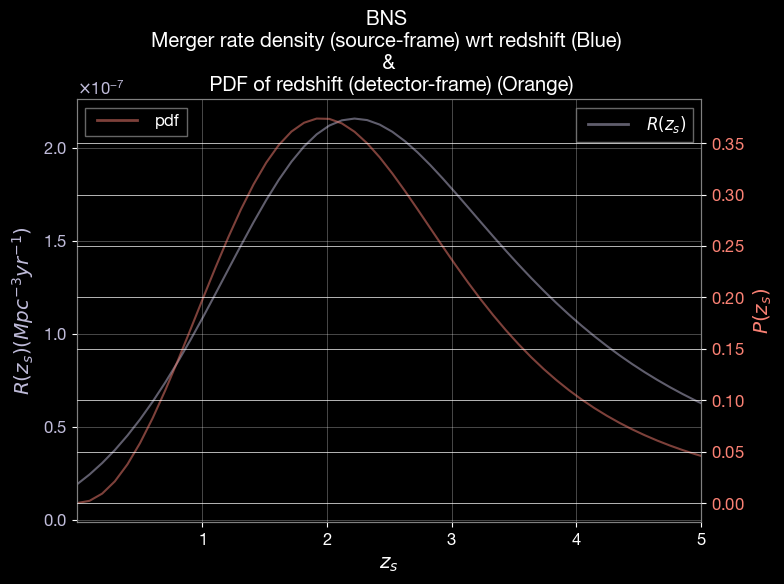

In [22]:
fig, ax1 = plt.subplots(figsize=(8, 6))

zs = np.linspace(0.001, 10.0, 100)
Rzs = ler.merger_rate_density.function(zs)
Rzs_det_pdf = ler.merger_rate_density_detector_frame.pdf(zs)

color = 'C2'
ax1.set_xlabel(r'$z_s$')
ax1.set_ylabel(r"$R(z_s) (Mpc^{-3} yr^{-1})$", color=color)
ax1.plot(zs, Rzs, color=color, linestyle='-', alpha=0.5, label=r"$R(z_s)$")
ax1.tick_params(axis='y', labelcolor=color)
# grid
ax1.grid(alpha=0.4)
# legend
legend = ax1.legend(loc='upper right', handlelength=3)
# Modify line width for legend entries
for handle in legend.get_lines():
    handle.set_linewidth(2)  # Set legend line width to be thinner
# x-range
ax1.set_xlim(0.001, 5)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'C3'
ax2.set_ylabel(r'$P(z_s)$', color=color)  # we already handled the x-label with ax1
ax2.plot(zs, Rzs_det_pdf, color=color, linestyle='-', alpha=0.5, label="pdf")
ax2.tick_params(axis='y', labelcolor=color)
# legend
legend = ax2.legend(loc='upper left', handlelength=3)
# Modify line width for legend entries
for handle in legend.get_lines():
    handle.set_linewidth(2)  # Set legend line width to be thinner

plt.title("BNS \nMerger rate density (source-frame) wrt redshift (Blue) \n & \n PDF of redshift (detector-frame) (Orange)")
plt.tight_layout()
plt.savefig("BNS_Merger_rate_density_and_PDF_of_redshift.png")
plt.show()

## Model Comparison

In [1]:
from ler.gw_source_population import CBCSourceRedshiftDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
ler = CBCSourceRedshiftDistribution(
    npool=4,
    z_min=0.001,
    z_max=10.0,
    event_type="BBH",
    merger_rate_density="merger_rate_density_madau_dickinson_belczynski_ng",
    merger_rate_density_param=dict(
                R0=19 * 1e-9, alpha_F=2.57, beta_F=5.83, c_F=3.36
    ),
    create_new_interpolator=dict(
        merger_rate_density=dict(create_new=create_new, resolution=500),
        redshift_distribution=dict(create_new=create_new, resolution=500),
    )
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_7.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_8.json
source_redshift interpolator will be generated at ./interpolator_json/source_redshift/source_redshift_3.json


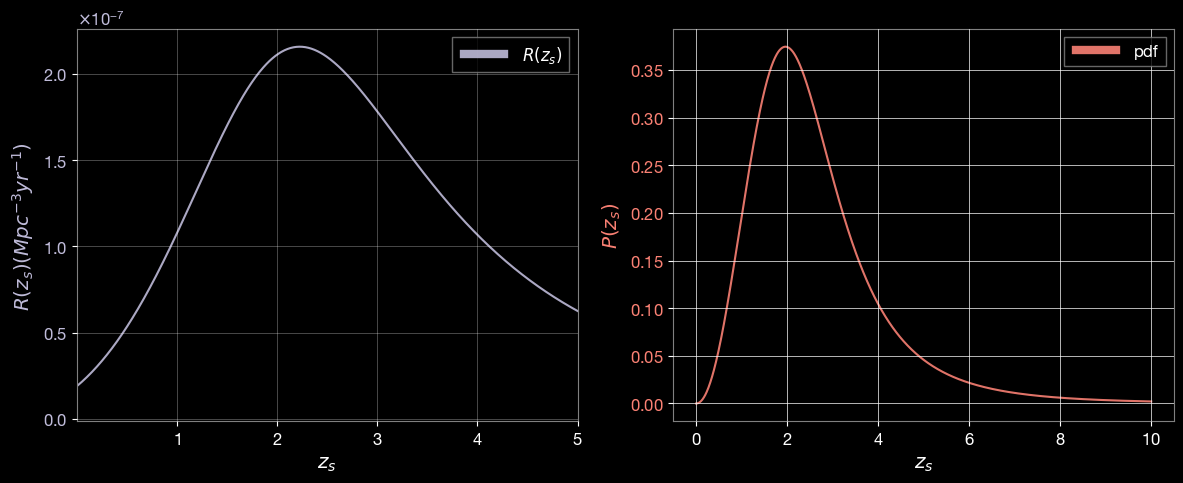

In [8]:
z = np.linspace(0.001, 10, 1000)
Rzs_ng = ler.merger_rate_density.function(z)
Rzs_pdf_ng = ler.merger_rate_density_based_source_redshift.pdf(z)

# right panel Rzs and right panel Rzs_det_pdf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(z, Rzs_ng, color='C2', linestyle='-', alpha=0.9, label=r"$R(z_s)$")
ax1.set_xlabel(r'$z_s$')
ax1.set_ylabel(r"$R(z_s) (Mpc^{-3} yr^{-1})$", color='C2')
ax1.tick_params(axis='y', labelcolor='C2')
ax1.grid(alpha=0.4)
ax1.legend(loc='upper right', handlelength=3)
ax1.set_xlim(0.001, 5)
ax2.plot(z, Rzs_pdf_ng, color='C3', linestyle='-', alpha=0.9, label="pdf")
ax2.set_xlabel(r'$z_s$')
ax2.set_ylabel(r'$P(z_s)$', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')
ax2.legend(loc='upper right', handlelength=3)
plt.tight_layout()
plt.show()


In [1]:
from ler.gw_source_population import CBCSourceRedshiftDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True
ler = CBCSourceRedshiftDistribution(
    npool=4,
    z_min=0.001,
    z_max=10.0,
    event_type="BBH",
    merger_rate_density="merger_rate_density_madau_dickinson2014",
    merger_rate_density_param=dict(
                R0=89 * 1e-9, a=0.015, b=2.7, c=2.9, d=5.6
    ),
    create_new_interpolator=dict(
        merger_rate_density=dict(create_new=create_new, resolution=500),
        redshift_distribution=dict(create_new=create_new, resolution=500),
    )
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson2014
merger_rate_density_madau_dickinson2014 interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson2014_14.json
merger_rate_density_madau_dickinson2014_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson2014_detector_frame_15.json
source_redshift interpolator will be generated at ./interpolator_json/source_redshift/source_redshift_6.json


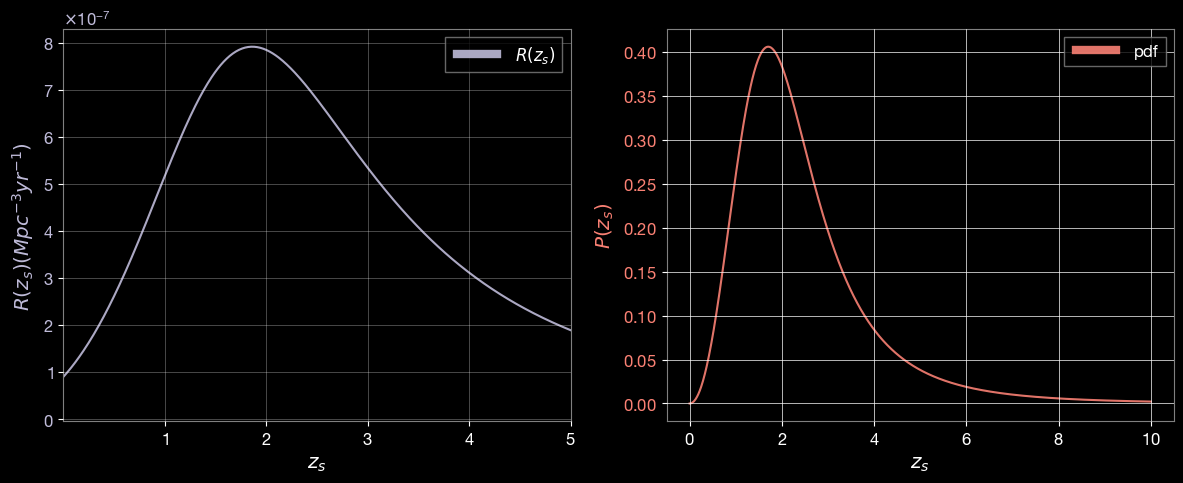

In [2]:
z = np.linspace(0.001, 10, 1000)
Rzs_mnd_bns = ler.merger_rate_density.function(z)
Rzs_pdf_mnd_bns = ler.merger_rate_density_based_source_redshift.pdf(z)

# right panel Rzs and right panel Rzs_det_pdf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(z, Rzs_mnd_bns, color='C2', linestyle='-', alpha=0.9, label=r"$R(z_s)$")
ax1.set_xlabel(r'$z_s$')
ax1.set_ylabel(r"$R(z_s) (Mpc^{-3} yr^{-1})$", color='C2')
ax1.tick_params(axis='y', labelcolor='C2')
ax1.grid(alpha=0.4)
ax1.legend(loc='upper right', handlelength=3)
ax1.set_xlim(0.001, 5)
ax2.plot(z, Rzs_pdf_mnd_bns, color='C3', linestyle='-', alpha=0.9, label="pdf")
ax2.set_xlabel(r'$z_s$')
ax2.set_ylabel(r'$P(z_s)$', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')
ax2.legend(loc='upper right', handlelength=3)
plt.tight_layout()
plt.show()


In [1]:
from ler.gw_source_population import CBCSourceRedshiftDistribution
import numpy as np
import matplotlib.pyplot as plt

create_new = True

ler_popI_II = CBCSourceRedshiftDistribution(
    npool=4,
    z_min=0.001,
    z_max=40.0,
    event_type="BBH",
    merger_rate_density="merger_rate_density_bbh_oguri2018",
    merger_rate_density_param=dict(
        R0=19 * 1e-9, b2=1.6, b3=2.1, b4=30
    ),
    create_new_interpolator=dict(
        merger_rate_density=dict(create_new=create_new, resolution=500),
        redshift_distribution=dict(create_new=create_new, resolution=500),
    )
)

ler_popIII = CBCSourceRedshiftDistribution(
    npool=4,
    z_min=0.001,
    z_max=40.0,
    event_type="BBH",
    merger_rate_density="merger_rate_density_bbh_popIII_ken2022",
    merger_rate_density_param=dict(
        n0=19.2 * 1e-9, aIII=0.66, bIII=0.3, zIII=11.6
    ),
    create_new_interpolator=dict(
        merger_rate_density=dict(create_new=create_new, resolution=500),
        redshift_distribution=dict(create_new=create_new, resolution=500),
    )
)

ler_primordial = CBCSourceRedshiftDistribution(
    npool=4,
    z_min=0.001,
    z_max=40.0, 
    event_type="BBH",
    merger_rate_density="merger_rate_density_bbh_primordial_ken2022",
    merger_rate_density_param=dict(
        R0=0.044 * 1e-9, t0=13.786885302009708
    ),
    create_new_interpolator=dict(
        merger_rate_density=dict(create_new=create_new, resolution=500),
        redshift_distribution=dict(create_new=create_new, resolution=500),
    )
)


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_1.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_1.json
using ler available merger rate density model: merger_rate_density_bbh_oguri2018
merger_rate_density_bbh_oguri2018 interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_bbh_oguri2018_19.json
merger_rate_density_bbh_oguri2018_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_bbh_oguri2018_detector_frame_20.json
source_redshift interpolator will be generated at ./interpolator_json/source_redshift/source_redshift_8.json

Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_d

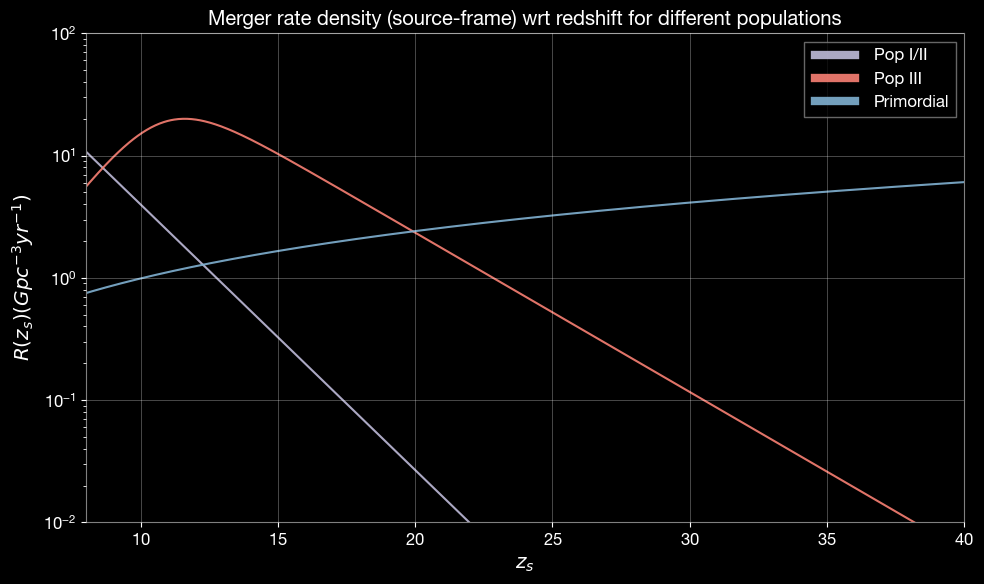

In [ ]:
# compare the three populations
z = np.linspace(0.001, 40.0, 1000)
Rzs_popI_II = ler_popI_II.merger_rate_density.function(z)
Rzs_popIII = ler_popIII.merger_rate_density.function(z)
Rzs_primordial = ler_primordial.merger_rate_density.function(z)

# plot
plt.figure(figsize=(10, 6))
# convert from Mpc^-3 yr^-1 to Gpc^-3 yr^-1
plt.plot(z, Rzs_popI_II*1e9, color='C2', linestyle='-', alpha=0.9, label=r"Pop I/II")
plt.plot(z, Rzs_popIII*1e9, color='C3', linestyle='-', alpha=0.9, label=r"Pop III")
plt.plot(z, Rzs_primordial*1e9, color='C4', linestyle='-', alpha=0.9, label=r"Primordial")
plt.xlabel(r'$z_s$')
plt.ylabel(r"$R(z_s) (ggGpc^{-3} yr^{-1})$")
plt.yscale('log')
plt.xlim(8, 40)
plt.ylim(1e-2, 1e2)
plt.grid(alpha=0.4)
plt.legend(loc='upper right', handlelength=3)
plt.title("Merger rate density (source-frame) wrt redshift for different populations")
plt.tight_layout()
plt.show()